In [1]:
import os
import re
import glob
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from kcore_functions import *


def extract_threshold_and_episode(folder_path):
    """
    Extracts the threshold and episode number from a folder path like:
    '.../collapsed_model_thr_03_000051'

    Returns:
        Tuple[float, int]: (threshold, episode)
    """
    match = re.search(r'thr_(\d{2})_(\d{6})', folder_path)
    if not match:
        raise ValueError(f"Could not extract threshold and episode from: {folder_path}")
    
    threshold = int(match.group(1)) / 10  # e.g., 03 → 0.3
    episode = int(match.group(2))         # e.g., 000051 → 51
    return threshold, episode

def get_fibers_info(path_original,threshold):
    results = []
    pt_files = glob.glob(os.path.join(path_original, 'model_*.pt'))
    for pt_file in pt_files:
        model_collapse_lstm, fibers =  collapse_model(pt_file, threshold)
        epoch = int(os.path.basename(pt_file).split('model_')[-1].split('.pt')[0])
        clusters_linear = torch.tensor(fibers[list(fibers.keys())[3]][-1])
        clusters_lstm = torch.tensor(fibers[list(fibers.keys())[4]][-1])
        
        unique_linear = torch.unique(clusters_linear).numel()
        unique_lstm = torch.unique(clusters_lstm).numel()

        n_params = number_of_parameters(model_collapse_lstm)
        
        results.append([
            epoch,
            unique_linear,
            unique_lstm,
            n_params
        ])

    return pd.DataFrame(results, columns=[
        f'epoch',
        f'fibers_l',
        f'fibers_lstm',
        f'n_params',
    ])

    # Collapse function. Matteo Serafino
    
def collapse_model(pt_file, threshold):
    """
    Loads a model and collapses its Linear and LSTM layers based on fiber clustering at the given threshold.

    Args:
        pt_file (str): Path to the model checkpoint (.pt file).
        threshold (float): Fiber clustering threshold (typically between 0 and 2).

    Returns:
        Tuple[torch.nn.Module, dict]: Collapsed model and corresponding fiber clustering data.
    """
    
    model = torch.load(pt_file, weights_only=False, map_location='cpu')
    fibers = get_fibers_vs_time([pt_file], threshold)

    clusters_linear = torch.tensor(fibers[list(fibers.keys())[3]][-1])
    clusters_lstm = torch.tensor(fibers[list(fibers.keys())[4]][-1])
        

    model_collapse_linear = collapse_linear_layer(model, clusters_linear)
    new_linear_clusters = torch.arange(model_collapse_linear.policy.policy.network[7].weight.shape[0])
    model_collapse_lstm = collapse_lstm(model_collapse_linear, new_linear_clusters, clusters_lstm)

    return model_collapse_lstm,fibers

## Paths to files

In [2]:
# === Define paths to log files and fiber data ===
log_original = 'log_second.out'
path_original = 'experiments/beam_rider-d04b5253/'

log_collapsed = 'log_collapsed.out'
path_collapsed = 'experiments/beam_rider-e3d19a76/collapsed_model_thr_03_000051/beam_rider-df7050da/'

# === Extract threshold and episode from collapsed model path ===
threshold, episode = extract_threshold_and_episode(path_collapsed)

# === Parse logs and extract relevant metrics ===
log_info_original = parse_pufferlib_log(log_original)[['epoch', 'episode_return']]
log_info_collapsed = parse_pufferlib_log(log_collapsed)[['epoch', 'episode_return']]

# === Load fiber clustering information ===
fibers_info_original = get_fibers_info(path_original, threshold)
fibers_info_collapsed = get_fibers_info(path_collapsed, threshold)

# === Ensure chronological order by sorting by training epoch ===
fibers_info_original = fibers_info_original.sort_values(by='epoch')
fibers_info_collapsed = fibers_info_collapsed.sort_values(by='epoch')

In [3]:
fibers_info_collapsed

,epoch,fibers_l,fibers_lstm,n_params
53,3,297,230,1587559
47,6,288,230,1548166
22,9,273,226,1470775
54,12,267,225,1441719
76,15,266,221,1425898
...,...,...,...,...
67,237,197,242,1182187
39,240,198,243,1189362
45,243,197,245,1190449
21,246,198,245,1194886


## Plot

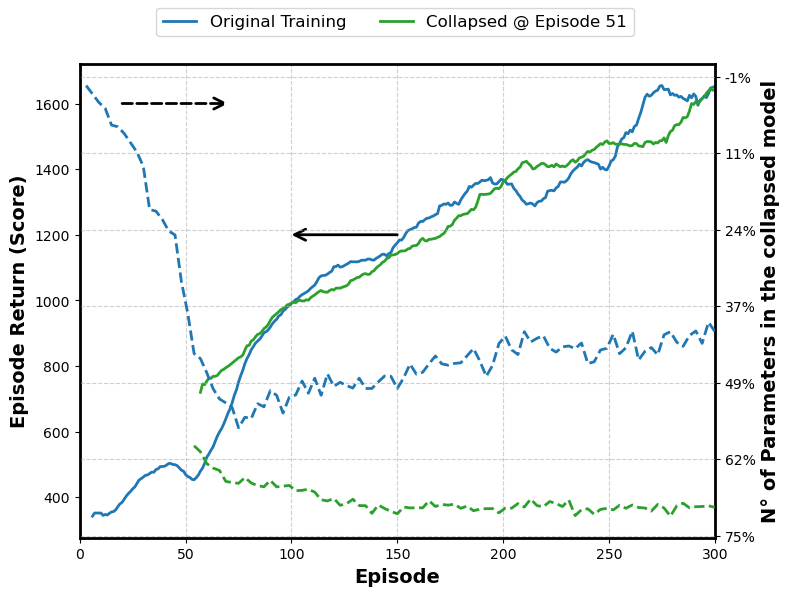

In [9]:
# Set moving average window size
window = 25

# Smooth episode return curves with moving average
log_info_original['smoothed'] = log_info_original['episode_return'].rolling(window, min_periods=5).mean()
log_info_collapsed['smoothed'] = log_info_collapsed['episode_return'].rolling(window, min_periods=5).mean()

# Create figure and two y-axes
fig, ax1 = plt.subplots(figsize=(8, 6))
ax2 = ax1.twinx()  # Second axis shares the same x-axis

# Set line width for all plot borders
for pos in ['top', 'right', 'bottom', 'left']:
    ax1.spines[pos].set_linewidth(2)

# === EPISODE RETURNS ===
# Plot original training return
ax1.plot(
    log_info_original.index,
    log_info_original['smoothed'],
    label='Original Training',
    color='tab:blue',
    linewidth=2
)

# Plot collapsed training return (shifted by starting episode)
ax1.plot(
    log_info_collapsed.index + episode,
    log_info_collapsed['smoothed'],
    label=f'Collapsed @ Episode {episode}',
    color='tab:green',
    linewidth=2
)

# Label x and left y axis
ax1.set_xlabel('Episode', fontsize=14, fontweight='bold')
ax1.set_ylabel('Episode Return (Score)', fontsize=14, fontweight='bold')

# === FIBER CLUSTERS ===
# Plot linear fiber cluster counts before and after collapse
ax2.plot(
    fibers_info_original['epoch'],
    fibers_info_original['n_params'],
    linestyle='--',
    color='tab:blue',
    linewidth=2
)
ax2.plot(
    fibers_info_collapsed['epoch'] + episode,
    fibers_info_collapsed['n_params'],
    linestyle='--',
    color='tab:green',
    linewidth=2
)

# Format right y-axis as reduction percentage (assuming 512 units as baseline)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{(100- (y / fibers_info_original['n_params'].max() * 100)):.0f}%'))
#ax2.set_ylabel('Fiber Reduction (Linear Layer)', fontsize=14, fontweight='bold')
ax2.set_ylabel('N° of Parameters in the collapsed model', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y')

# Add grid lines
ax1.grid(True, axis='x', linestyle='--', alpha=0.6)
ax2.grid(True, axis='y', linestyle='--', alpha=0.6)


#=== ARROWS ===
arrow_style2 = dict(
    facecolor='black',
    edgecolor='black',
    linestyle='--',
    linewidth=2,
    arrowstyle='->',
    shrinkA=0, shrinkB=0,
    mutation_scale=20  # Default is ~10; increase for bigger head
)
ax1.annotate('', xy=(70, 1600), xytext=(20, 1600),
             arrowprops=arrow_style2)

# Arrow pointing to the rising orange line
arrow_style = dict(
    facecolor='black',
    edgecolor='black',
    linestyle='-',
    linewidth=2,
    arrowstyle='->',
    shrinkA=0, shrinkB=0,
    mutation_scale=20  # Default is ~10; increase for bigger head
)
ax1.annotate('', xy=(100, 1200), xytext=(150, 1200),
             arrowprops=arrow_style)

# === LEGEND ===
# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles=handles1 + handles2, labels=labels1 + labels2, loc='upper center', ncol=3, fontsize=12)

# Set x-axis limits
ax1.set_xlim([0, 300])
#ax2.set_ylim(200, 514)
# Layout adjustment and save
plt.tight_layout(rect=[0, 0, 1, 0.92])  # Leave room for legend
plt.savefig('Collapse.png', bbox_inches='tight')
plt.show()
